# loading dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = Path("../data")

df = pd.read_csv(data_dir/"loan_approval_dataset.csv")

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# analyzing dataset

In [2]:
df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [68]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# checking any null values present 

In [17]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

# checking any duplicates present

In [18]:
df.duplicated().sum()

np.int64(0)

# dorpping column loan_id -> no use

In [3]:
df = df.drop("loan_id", axis = 1)

In [20]:
df.head(2)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected


# columns name and data contains some space -> removed str.strip()

In [4]:
df.columns = df.columns.str.strip()

# checking is data biased or unbiased

In [58]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [28]:
df.groupby('education')['education'].count()

education
Graduate        2144
Not Graduate    2125
Name: education, dtype: int64

In [29]:
df['self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [32]:
df.groupby("self_employed")['self_employed'].count()

self_employed
No     2119
Yes    2150
Name: self_employed, dtype: int64

In [35]:
df.groupby(["education", "self_employed"])['education'].count()

education     self_employed
Graduate      No               1089
              Yes              1055
Not Graduate  No               1030
              Yes              1095
Name: education, dtype: int64

In [44]:
df.loc[0, 'education']

' Graduate'

# data contains some space -> removed str.strip()

In [5]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

# converting categorical value into 1 and 0 as only types present 

In [7]:
df['education'] = df['education'].replace({"Graduate": 1, "Not Graduate": 0})
df['self_employed'] = df['self_employed'].replace({"Yes": 1, "No" : 0})

df['self_employed']

0       0
1       1
2       0
3       0
4       1
       ..
4264    1
4265    1
4266    0
4267    0
4268    0
Name: self_employed, Length: 4269, dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   no_of_dependents          4269 non-null   int64 
 1   education                 4269 non-null   int64 
 2   self_employed             4269 non-null   int64 
 3   income_annum              4269 non-null   int64 
 4   loan_amount               4269 non-null   int64 
 5   loan_term                 4269 non-null   int64 
 6   cibil_score               4269 non-null   int64 
 7   residential_assets_value  4269 non-null   int64 
 8   commercial_assets_value   4269 non-null   int64 
 9   luxury_assets_value       4269 non-null   int64 
 10  bank_asset_value          4269 non-null   int64 
 11  loan_status               4269 non-null   object
dtypes: int64(11), object(1)
memory usage: 400.3+ KB


In [75]:
df.describe()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2.498712,0.502225,0.503631,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1.695910,0.500054,0.500045,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,0.000000,0.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1.000000,0.000000,0.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,3.000000,1.000000,1.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,4.000000,1.000000,1.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,5.000000,1.000000,1.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


# got clean data now time to plot

# plotting data against count to check data biased, unbiased or analyzing

array([[<Axes: title={'center': 'no_of_dependents'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'self_employed'}>],
       [<Axes: title={'center': 'income_annum'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'loan_term'}>],
       [<Axes: title={'center': 'cibil_score'}>,
        <Axes: title={'center': 'residential_assets_value'}>,
        <Axes: title={'center': 'commercial_assets_value'}>],
       [<Axes: title={'center': 'luxury_assets_value'}>,
        <Axes: title={'center': 'bank_asset_value'}>, <Axes: >]],
      dtype=object)

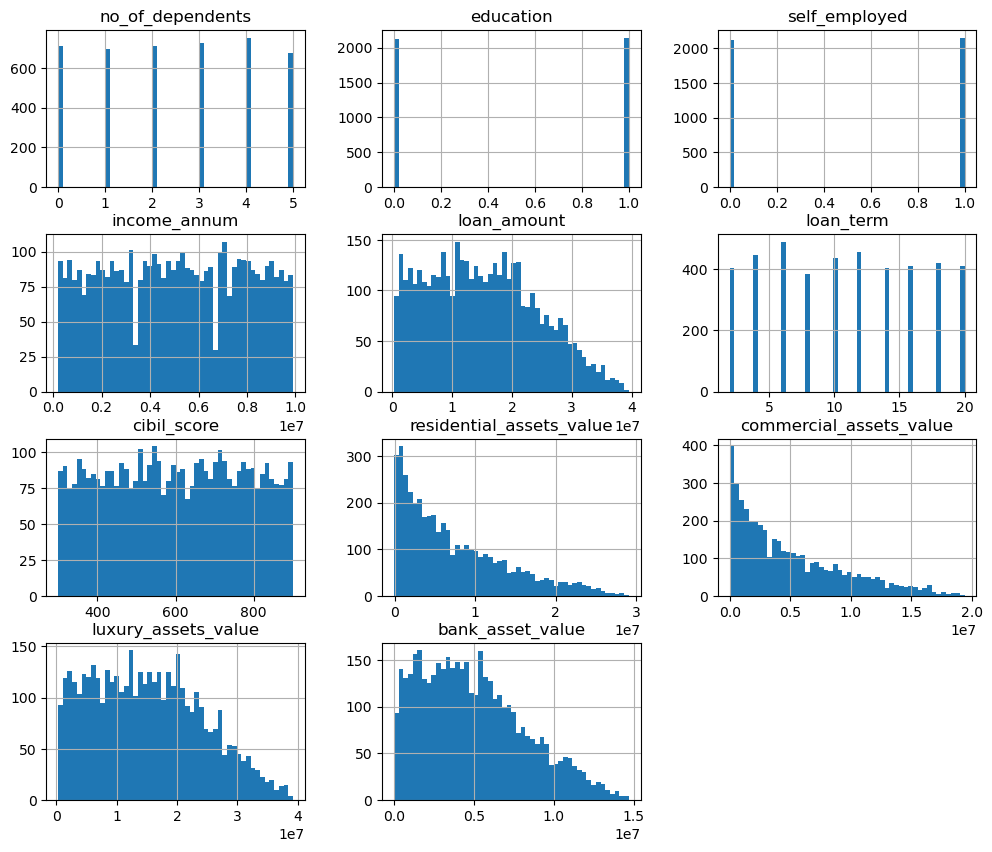

In [9]:
df.hist(bins = 50, figsize = (12,10) )

In [10]:
df_copy = df.copy()
df_copy['loan_status'] = df_copy['loan_status'].map({"Approved": 1, "Rejected": 0})

# sns.heatmap(df_corr, annot = True, cmap = 'coolwarm')

# correlation metrics 

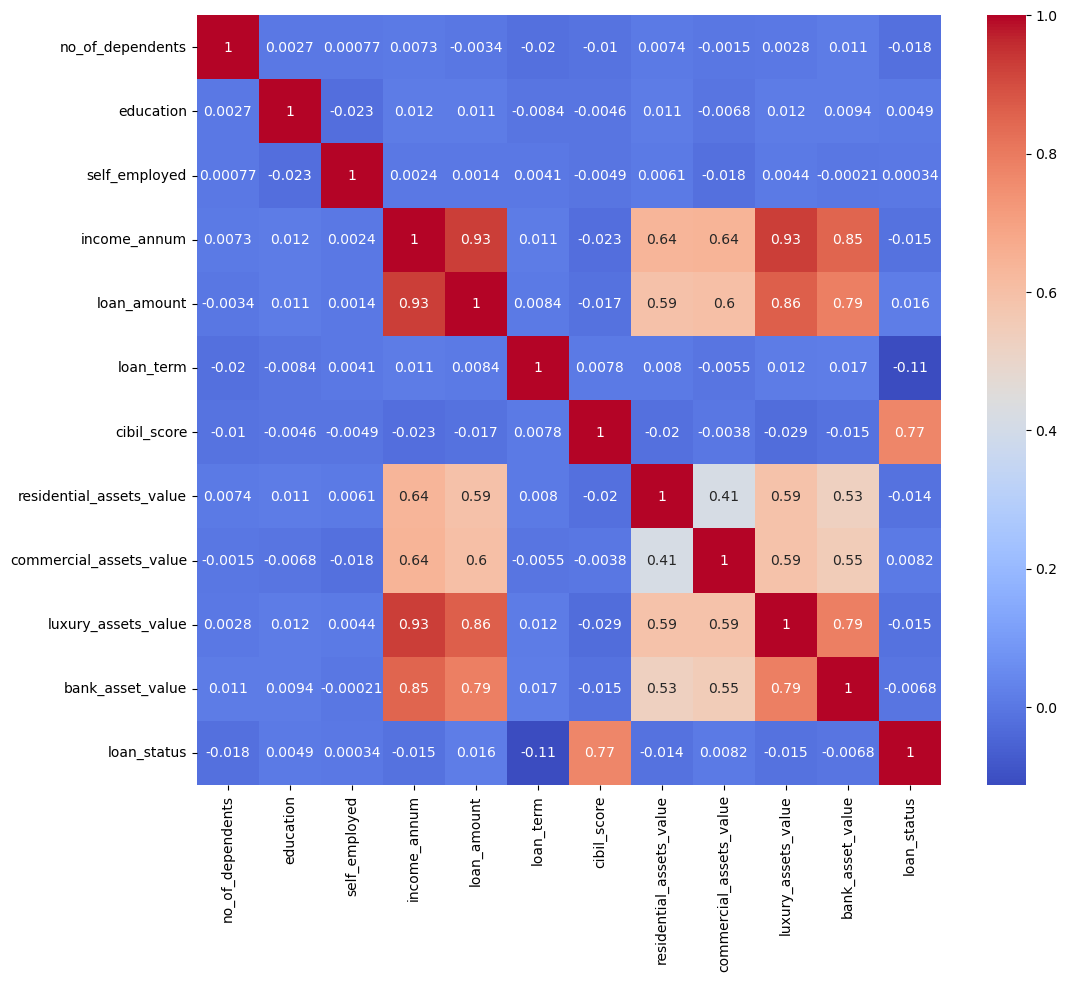

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (12, 10))
sns.heatmap(df_copy.corr(), annot = True, cmap = 'coolwarm')

plt.show()

In [12]:
df_copy.corr()['loan_status'].sort_values(ascending=False)

loan_status                 1.000000
cibil_score                 0.770518
loan_amount                 0.016150
commercial_assets_value     0.008246
education                   0.004918
self_employed               0.000345
bank_asset_value           -0.006778
residential_assets_value   -0.014367
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status, dtype: float64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

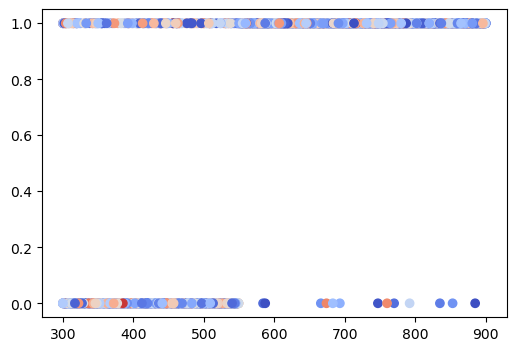

In [15]:
fig = plt.figure(figsize = (6, 4) )

x = df_copy['cibil_score']
y = df_copy['loan_status']

plt.scatter(x, y, c = df_copy['loan_amount'], cmap = 'coolwarm')

plt.show()

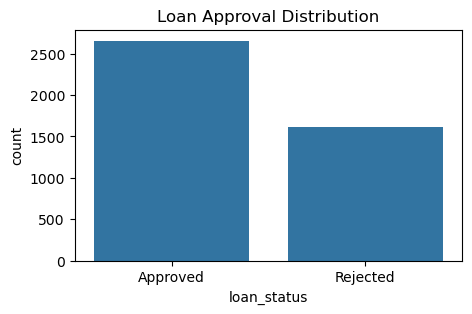

In [24]:
fig = plt.figure(figsize = (5, 3))
sns.countplot(data=df, x='loan_status')
plt.title('Loan Approval Distribution')
plt.show()

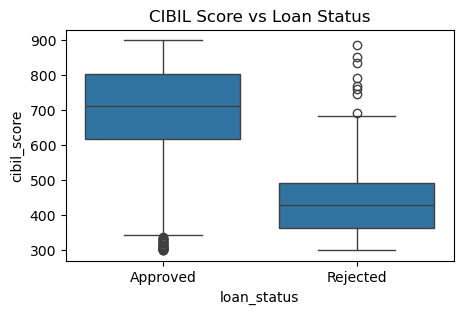

In [25]:
fig = plt.figure(figsize = (5, 3))
sns.boxplot(data=df, x='loan_status', y='cibil_score')
plt.title('CIBIL Score vs Loan Status')
plt.show()

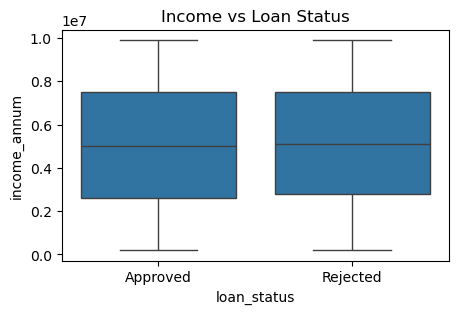

In [26]:
fig = plt.figure(figsize = (5, 3))
sns.boxplot(data=df, x='loan_status', y='income_annum')
plt.title('Income vs Loan Status')
plt.show()

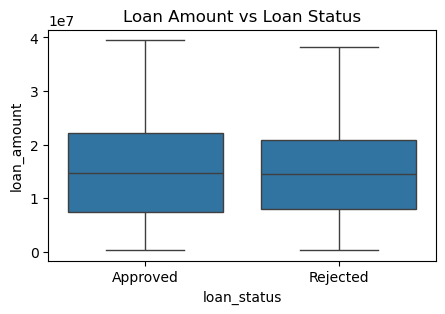

In [27]:
fig = plt.figure(figsize = (5, 3))
sns.boxplot(data=df, x='loan_status', y='loan_amount')
plt.title('Loan Amount vs Loan Status')
plt.show()

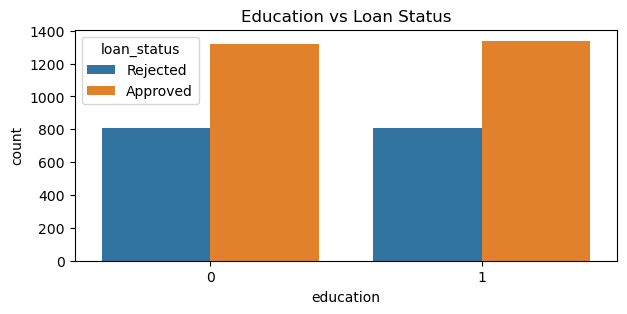

In [30]:
fig = plt.figure(figsize = (7, 3))
sns.countplot(data=df, x='education', hue='loan_status')
plt.title('Education vs Loan Status')
plt.show()

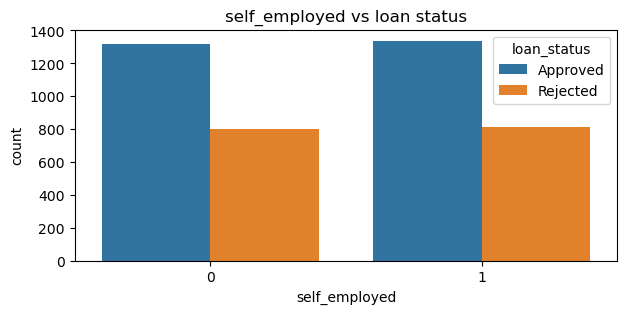

In [31]:
fig = plt.figure(figsize = (7, 3))
sns.countplot(data=df, x='self_employed', hue='loan_status')
plt.title('self_employed vs loan status')
plt.show()

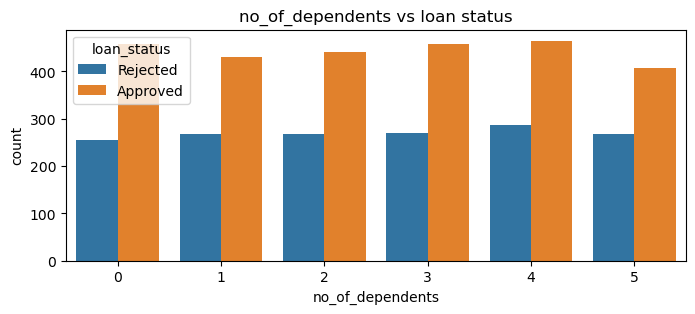

In [33]:
fig = plt.figure(figsize = (8, 3))
sns.countplot(data = df, x = 'no_of_dependents', hue = 'loan_status')
plt.title("no_of_dependents vs loan status")
plt.show()

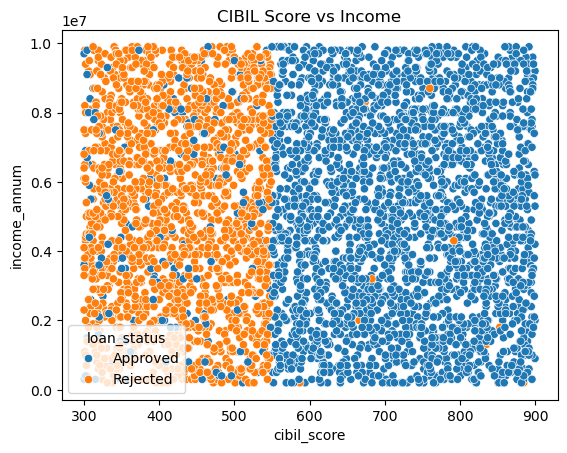

In [34]:
sns.scatterplot(data=df, x='cibil_score', y='income_annum', hue='loan_status')
plt.title('CIBIL Score vs Income')
plt.show()

In [36]:
data_dir = Path("../data")

df.to_csv(data_dir/"clean_dataset.csv", index = False)
print("done")

done


# from plots 
- loan status mostly depend upon cibil score
- approved is more than rejected
- status has less dependency on income_annum, graduate, self_employed, no_of_dependents
- same amount of loan can be rejected or approved based on cibil score
